# 13 -- CC-OR-Net (Conditional Cascaded Ordinal-Residual Networks)

Адаптация Meituan CC-OR-Net (WWW'26) поверх готового `data/lstm/` пайплайна из [06_LSTM_Data_Preparation.ipynb](../06_LSTM_Data_Preparation.ipynb). Ориентир -- Hurdle BiLSTM из [07_LSTM.ipynb](../07_LSTM.ipynb), Public RMSLE **1.6529693117**.

Код модели -- в `src/`, ноутбук -- только сборка и запуск (структура как в [two_stage/](../two_stage/)). Юнит-тесты: `pytest tests/`.

## Результаты

| прогон | эпох | `T_max` | lr в момент сабмита | Public RMSLE |
|---|---:|---:|---:|---:|
| финальное #1 | 2 | 2 | 1e-6 | 1.6665662616 |
| финальное #2 | 10 | 10 | 1e-6 | **1.6598552938** |
| контрольная точка | 25 | 100 | 1.71e-3 | 1.6668056004 |
| контрольная точка | 50 | 100 | 1.00e-3 | 1.6756911584 |
| контрольная точка | 75 | 100 | 2.94e-4 | не отправлялся |
| контрольная точка | 100 | 100 | 1e-6 | 1,6821222853 |

**Лучший результат CC-OR-Net -- 1.6599 на 10 эпохах.** До `07_LSTM` (1.6530) не дотянули. После 10 эпохи public rmsle растёт, наблюдаем **переобучение**.

## План прогона

1. Окружение.
2. Гиперпараметры.
3. Bucket-пороги и denorm-статистики -- быстрая проверка перед долгим обучением.
4. Sanity-check: необученная модель обязана совпасть с тривиальным «всегда 0».
5. **Диагностический** holdout-прогон -- посмотреть на лоссы и ошибки, не выбирать эпохи.
6. Анализ ошибок: confusion-матрица бакетов, scatter, топ-промахи.
7. Финальное обучение на всех 10 cutoff с сабмитом на контрольных точках.
8. Сравнение сабмитов между собой и итоги.

## Архитектура

1. **SharedEncoder** -- `h` (128) = MLP над `concat(sequence_repr[256], static_repr[128])`; sequence/static ветки повторяют `HybridLSTM` из `07_LSTM.ipynb`.
2. **CascadeHead** -- 2 бинарных классификатора по chain rule: `P(y>0)` и `P(y>tau2 | y>0)`; отсюда вероятности 3 бакетов (`0` / нижняя половина позитивов / верхняя).
3. **FeatureAlignment (GLU)** -- гейт над `concat(h, bucket_probs, bucket_embedding)`.
4. **ResidualRegressionHead** -- 2 residual-блока, `tanh` в `[-1,1]`, денормализация по квантилям бакета.
5. **WhaleAugmentation** -- доп. градиент только для бакета 2, только при обучении. **Отключён (`W_WHALE=0.0`)**: на 250k пользователей его градиент схлопывается (0.0345 -> 0.0002), вклада не даёт.

Прогноз собирается в **soft**-режиме: `log1p(pred) = sum_b P(b) * (v_norm*r_b + c_b)`. Это принципиально: на том же чекпоинте `argmax` даёт **2.049**, а `soft` -- **1.678**. RMSLE штрафует квадрат ошибки в log-пространстве, поэтому при неуверенном каскаде выгоднее промежуточное значение, чем самый вероятный бакет. Тот же приём используется в `07_LSTM.ipynb` (`pred_log = probability * regressor_log`).

## 1. Окружение

In [19]:
import sys
from pathlib import Path

MODEL_DIR = Path.cwd().resolve()
SRC_INIT = MODEL_DIR / "src" / "__init__.py"

if not SRC_INIT.is_file():
    raise FileNotFoundError(
        "Notebook должен запускаться из 'notebooks/modeling/cc_or_net'"
    )

if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

In [20]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from src.data import (
    DATA_DIR,
    HOLDOUT_CUTOFF,
    HOLDOUT_TRAIN_CUTOFFS,
    INFERENCE_CUTOFF,
    LABELED_CUTOFFS,
    META,
    PROJECT_ROOT,
    make_loader,
)
from src.features import fit_static_stats, normalize_static, sequence_input_size, static_input_size
from src.inference import assemble_prediction, predict_submission
from src.model import CCORNet
from src.train import evaluate_holdout, train_ccornet

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from validation import rmsle  # корневой src/validation.py -- метрика соревнования

BASE_INDEX = {name: i for i, name in enumerate(META["base_sequence_features"])}
STATIC_LOG_INDICES = [
    META["static_features"].index(name) for name in META["static_log_copy_features"]
]
SEQ_FEATURE_SIZE = sequence_input_size(META["base_sequence_features"], META["calendar_sequence_features"])
STATIC_FEATURE_SIZE = static_input_size(META["static_features"], META["static_log_copy_features"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")
print("cpu count:", os.cpu_count())
print("sequence features:", SEQ_FEATURE_SIZE, "| static features:", STATIC_FEATURE_SIZE)

MODELS_DIR = PROJECT_ROOT / "models" / "cc_or_net"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR = PROJECT_ROOT / "submissions"
SUBMISSIONS_DIR.mkdir(exist_ok=True)

# static-статистики по HOLDOUT_TRAIN_CUTOFFS -- нужны только sanity-check'у ниже;
# train_ccornet пересчитывает их внутри себя тем же кодом для самого обучения.
static_stats = fit_static_stats(HOLDOUT_TRAIN_CUTOFFS, DATA_DIR, STATIC_FEATURE_SIZE, STATIC_LOG_INDICES)

device: cuda | NVIDIA A100-SXM4-40GB
cpu count: 12
sequence features: 40 | static features: 241


## 2. Гиперпараметры

In [21]:
GRAD_CLIP_NORM = 5.0
WARMUP_STEPS = 200
LR = 2e-3
WEIGHT_DECAY = 5e-4
BATCH_SIZE = 1024
PREDICTION_MODE = "soft"   # argmax даёт 2.049 против 1.678 у soft на том же чекпоинте
W_WHALE = 0.0              # whale не заводится на 250k пользователей

TOTAL_EPOCHS = 100
MILESTONES = [25, 50, 75, 100]   # на каждой -- сабмит

print("конфигурация:", dict(lr=LR, warmup=WARMUP_STEPS, clip=GRAD_CLIP_NORM,
                            w_whale=W_WHALE, mode=PREDICTION_MODE,
                            epochs=TOTAL_EPOCHS, milestones=MILESTONES))

конфигурация: {'lr': 0.002, 'warmup': 200, 'clip': 5.0, 'w_whale': 0.0, 'mode': 'soft', 'epochs': 100, 'milestones': [25, 50, 75, 100]}


## 3. Bucket-пороги и denorm-статистики

`tau2` -- медиана положительного `y` строго по `HOLDOUT_TRAIN_CUTOFFS`. Доли бакетов train vs holdout сравниваем глазами: если распределение «уехало», это сигнал нестационарности, и лучше увидеть его до многочасового обучения, а не после.

In [22]:
from src.data import assign_buckets, fit_bucket_denorm_stats, fit_bucket_threshold

tau2 = fit_bucket_threshold(HOLDOUT_TRAIN_CUTOFFS, data_dir=DATA_DIR)
denorm_stats = fit_bucket_denorm_stats(HOLDOUT_TRAIN_CUTOFFS, tau2, data_dir=DATA_DIR)

print(f"tau2 = {tau2:.4f}")
for bucket, (r_b, c_b) in denorm_stats.items():
    print(f"bucket {bucket}: r_b={r_b:.4f}, c_b={c_b:.4f}"
          f"   -> выразимый диапазон прогноза: [{np.expm1(c_b - r_b):.1f} .. {np.expm1(c_b + r_b):.1f}]")


def bucket_shares(cutoffs):
    y = np.concatenate([np.load(DATA_DIR / cutoff / "y.npy") for cutoff in cutoffs])
    counts = np.bincount(assign_buckets(y, tau2), minlength=3)
    return counts / counts.sum()


print()
print("доли бакетов (train cutoffs):  ", np.round(bucket_shares(HOLDOUT_TRAIN_CUTOFFS), 4))
print("доли бакетов (holdout cutoff): ", np.round(bucket_shares([HOLDOUT_CUTOFF]), 4))

tau2 = 70.4072
bucket 1: r_b=0.9656, c_b=3.2998   -> выразимый диапазон прогноза: [9.3 .. 70.2]
bucket 2: r_b=1.0243, c_b=5.2091   -> выразимый диапазон прогноза: [64.7 .. 508.5]

доли бакетов (train cutoffs):   [0.476 0.262 0.262]
доли бакетов (holdout cutoff):  [0.4593 0.2905 0.2502]


## 4. Sanity-check перед обучением

In [23]:
_loader = make_loader(HOLDOUT_CUTOFF, data_dir=DATA_DIR, tau2=tau2, with_target=True, batch_size=4096)
_seq, _static, _y, _bucket = next(iter(_loader))
_static_n = normalize_static(_static, static_stats, STATIC_LOG_INDICES)

_untrained = CCORNet(BASE_INDEX, SEQ_FEATURE_SIZE, STATIC_FEATURE_SIZE)
_untrained.eval()
with torch.no_grad():
    _out = _untrained(_seq, _static_n)

_pred = assemble_prediction(_out["bucket_probs"], _out["v_norm"], denorm_stats, mode="argmax")
_untrained_rmsle = rmsle(_y.numpy(), _pred)
_always_zero_rmsle = rmsle(_y.numpy(), np.zeros_like(_y.numpy()))
print("untrained-model RMSLE :", _untrained_rmsle)
print("always-zero RMSLE     :", _always_zero_rmsle)
assert abs(_untrained_rmsle - _always_zero_rmsle) < 1e-6, "необученная CCORNet обязана предсказывать всё как 0"
print("OK")

del _loader, _seq, _static, _y, _bucket, _static_n, _untrained, _out, _pred

untrained-model RMSLE : 3.225003932471865
always-zero RMSLE     : 3.225003932471865
OK


## 5. Диагностический прогон на holdout

Это проверка, что модель учится, и материал для анализа ошибок ниже. 
### Что означает каждый лосс

`total_loss` (`src/losses.py`) складывается из четырёх слагаемых:

```
total = w_cascade * (loss1 + loss2)  +  w_reg * loss_reg  +  w_whale * loss_whale
```

Все значения в логе -- **средние по эпохе**, взвешенные по размеру батча.

---

#### `loss1` -- каскад, первый вопрос: «будет ли покупка вообще?»

```
loss1 = BCEWithLogits(logit1, target = [y > 0])
```

Считается по **всем** строкам батча. Это ровно та же задача, что решает classifier в `07_LSTM.ipynb`.

- **Baseline «сигнала нет»: 0.6920.** Это энтропия базовой ставки: позитивов в train 52.40%, поэтому `-(0.524·ln0.524 + 0.476·ln0.476) = 0.6920`. Модель, которая всем подряд выдаёт 0.524, получит именно столько.

---

#### `loss2` -- каскад, второй вопрос: «покупка крупная?»

```
loss2 = BCEWithLogits(logit2, target = [y > tau2])   # только строки с y > 0
```

Считается **только по строкам с `bucket_true > 0`** (в этой эпохе это ~52% батча).

- **Baseline: 0.6931 (= `ln 2` в точности).** `tau2` -- это медиана позитивов по построению, поэтому среди позитивов ровно 50.00% попадают в бакет 2. Идеально сбалансированная бинарная задача.

---

#### `loss_reg` -- регрессия внутри бакета

```
v_target = clip((log1p(y) - c_b) / r_b, -1, 1)      # b -- ИСТИННЫЙ бакет
loss_reg = SmoothL1(v_norm, v_target)               # только строки с bucket_true > 0
```

Тоже только по позитивам (для бакета 0 прогноз всегда 0, регрессия там не определена). `(r_b, c_b)` берутся по **истинному** бакету -- это teacher forcing: иначе на старте обучения, пока каскад путается, регрессия получала бы таргет, посчитанный по неверным квантилям.

- **Baseline: 0.204.** Это ошибка стратегии «всегда предсказывать медиану своего бакета» (`v_norm = 0`).

---

#### `loss_whale` -- вспомогательная голова верхнего бакета

Focal-подобный BCE, считается **только по строкам `bucket_true == 2`**, таргет всегда 1 (по построению маски). В логе печатается **сырое значение, ДО умножения на `w_whale`**. 

При `W_WHALE = 0.0` он **не входит в `total`** и не даёт градиента -- показывается только для наблюдения. Отключён потому, что на 250k пользователей его градиент схлопывается (0.0345 -> 0.0002 за одну эпоху): у него самая узкая выборка и самая специализированная задача, и на нашем масштабе он не заводится.

---

#### `total` и `grad_norm`

- **`total`** -- то, что реально минимизируется.
- **`grad_norm`** -- L2-норма градиента **до** клиппинга, по параметрам `net` и `whale` вместе.

---

In [24]:
diag_net, diag_whale, diag_info = train_ccornet(
    BASE_INDEX,
    SEQ_FEATURE_SIZE,
    STATIC_FEATURE_SIZE,
    STATIC_LOG_INDICES,
    train_cutoffs=HOLDOUT_TRAIN_CUTOFFS,
    holdout_cutoff=HOLDOUT_CUTOFF,
    data_dir=DATA_DIR,
    rmsle_fn=rmsle,
    epochs=8,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    batch_size=BATCH_SIZE,
    w_whale=W_WHALE,
    device=DEVICE,
    log_every=0,               # только по эпохам, без построчного шума
    grad_clip_norm=GRAD_CLIP_NORM,
    warmup_steps=WARMUP_STEPS,
    mode=PREDICTION_MODE,
    checkpoint_path=MODELS_DIR / "ccor_net_diagnostic.pt",
)
print()
print("interrupted:", diag_info["interrupted"], "| эпох завершено:", diag_info["epochs_completed"])

run=holdout selection pred_mode=soft | device=cuda num_workers=10 pin_memory=True | 2048 batches/epoch | grad_clip_norm=5.0 warmup_steps=200

Лоссы в логе -- средние по эпохе. Что означает каждый:
  loss1      BCE каскада «y > 0?»           -- по ВСЕМ строкам батча.
             Baseline «угадывать по базовой ставке» = ln(2) ~ 0.693; ниже -- есть сигнал.
  loss2      BCE каскада «y > tau2 | y > 0?» -- ТОЛЬКО по строкам bucket>0
             (для y=0 условная вероятность не определена, они замаскированы).
             tau2 -- медиана позитивов, поэтому классы 50/50 и baseline тоже ~0.693.
  loss_reg   SmoothL1 регрессии v_norm против v_target -- только bucket>0, teacher
             forcing по ИСТИННОМУ бакету. Baseline «всегда медиана бакета» ~0.204.
  loss_whale focal-лосс whale-модуля, только bucket==2. Это СЫРОЕ значение ДО
             умножения на w_whale=0.0; в total входит уже с весом.
  total      w_cascade*(loss1+loss2) + w_reg*loss_reg + w_whale*loss_whale
  grad_norm  L2-нор

In [25]:
pd.DataFrame(diag_info["history"]).set_index("epoch")

,loss1,loss2,loss_reg,loss_whale,total,grad_norm,holdout_rmsle
epoch,,,,,,,
1,0.480671,0.589972,0.181676,0.148109,1.252319,0.224812,1.684993
2,0.476778,0.586625,0.180734,0.142726,1.244138,0.212948,1.675908
3,0.475800,0.585892,0.180492,0.146338,1.242184,0.210890,1.684804
4,0.475101,0.585095,0.180302,0.150875,1.240497,0.206682,1.684634
5,0.474475,0.584414,0.180158,0.153591,1.239047,0.196357,1.686043
6,0.473911,0.583516,0.180022,0.154669,1.237449,0.190689,1.680699
7,0.473346,0.582731,0.179918,0.154486,1.235994,0.189333,1.688007
8,0.472763,0.581991,0.179812,0.154672,1.234565,0.185578,1.682483


## 6. Анализ ошибок на holdout

Здесь смотрим, **где** модель ошибается -- это то, ради чего holdout вообще нужен.

In [26]:
for _mode in ("argmax", "soft"):
    _score, *_ = evaluate_holdout(
        diag_net, HOLDOUT_CUTOFF, DATA_DIR, diag_info["static_stats"], STATIC_LOG_INDICES,
        diag_info["tau2"], diag_info["denorm_stats"], rmsle, device=DEVICE, mode=_mode,
    )
    print(f"holdout RMSLE ({_mode:>6}): {_score:.5f}")

holdout_score, y_true, y_pred, bucket_true, bucket_pred = evaluate_holdout(
    diag_net, HOLDOUT_CUTOFF, DATA_DIR, diag_info["static_stats"], STATIC_LOG_INDICES,
    diag_info["tau2"], diag_info["denorm_stats"], rmsle, device=DEVICE, mode=PREDICTION_MODE,
)

print()
print(f"true zeros: {(y_true == 0).mean():.2%} | predicted exact zeros: {(y_pred == 0).mean():.2%}")
print("  (в soft-режиме ровный 0 требует P(bucket 0)=1, поэтому ~0% -- ожидаемо;")
print("   07_LSTM тоже даёт 0.00% точных нулей и при этом holdout 1.679)")
print()
print(f"cascade bucket accuracy: {(bucket_true == bucket_pred).mean():.2%}")
print()
print("RMSLE по ИСТИННЫМ бакетам:")
for b in (0, 1, 2):
    m = bucket_true == b
    print(f"  bucket {b}: n={int(m.sum()):6d}  rmsle={rmsle(y_true[m], y_pred[m]):.5f}")

holdout RMSLE (argmax): 2.04477
holdout RMSLE (  soft): 1.67591

true zeros: 45.93% | predicted exact zeros: 0.00%
  (в soft-режиме ровный 0 требует P(bucket 0)=1, поэтому ~0% -- ожидаемо;
   07_LSTM тоже даёт 0.00% точных нулей и при этом holdout 1.679)

cascade bucket accuracy: 64.27%

RMSLE по ИСТИННЫМ бакетам:
  bucket 0: n=114835  rmsle=1.69591
  bucket 1: n= 72621  rmsle=1.37089
  bucket 2: n= 62544  rmsle=1.94009


In [27]:
confusion = pd.crosstab(
    pd.Series(bucket_true, name="true"), pd.Series(bucket_pred, name="pred"),
).reindex(index=[0, 1, 2], columns=[0, 1, 2], fill_value=0)

print("confusion-матрица бакетов (строки = истина, столбцы = прогноз):")
print(confusion)
print()
rec = np.diag(confusion.to_numpy()) / confusion.to_numpy().sum(axis=1).clip(min=1)
for b, r in zip((0, 1, 2), rec):
    print(f"  recall bucket {b}: {r:.2%}")
print()
print("Ожидаемая картина: бакет 1 (мелкие покупки, 0 < y <= tau2) распознаётся хуже всех --")
print("он «средний» и размазан между соседями. Самая дорогая ошибка -- истинный бакет 2,")
print("предсказанный как 0: крупный покупатель, которого модель посчитала неактивным.")

confusion-матрица бакетов (строки = истина, столбцы = прогноз):
pred      0      1      2
true                     
0     95483  11231   8121
1     29043  22443  21135
2     10234   9572  42738

  recall bucket 0: 83.15%
  recall bucket 1: 30.90%
  recall bucket 2: 68.33%

Ожидаемая картина: бакет 1 (мелкие покупки, 0 < y <= tau2) распознаётся хуже всех --
он «средний» и размазан между соседями. Самая дорогая ошибка -- истинный бакет 2,
предсказанный как 0: крупный покупатель, которого модель посчитала неактивным.


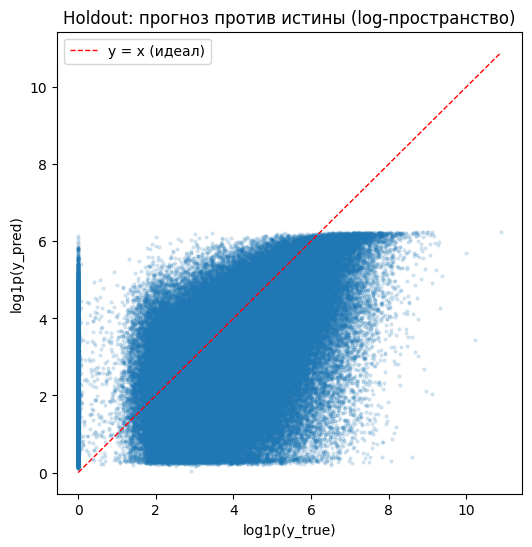

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.log1p(y_true), np.log1p(y_pred), s=4, alpha=0.15)
lim = max(np.log1p(y_true).max(), np.log1p(y_pred).max())
ax.plot([0, lim], [0, lim], color="red", lw=1, ls="--", label="y = x (идеал)")
ax.set_xlabel("log1p(y_true)"); ax.set_ylabel("log1p(y_pred)")
ax.set_title("Holdout: прогноз против истины (log-пространство)")
ax.legend(); plt.show()

In [29]:
holdout_user_ids = np.load(DATA_DIR / HOLDOUT_CUTOFF / "user_id.npy")
assert len(holdout_user_ids) == len(y_true), "evaluate_holdout не шаффлит -- порядок обязан совпасть"

log_err = np.abs(np.log1p(y_pred) - np.log1p(y_true))
worst = np.argsort(-log_err)[:20]
pd.DataFrame({
    "user_id": holdout_user_ids[worst],
    "y_true": y_true[worst],
    "y_pred": y_pred[worst],
    "bucket_true": bucket_true[worst],
    "bucket_pred": bucket_pred[worst],
    "abs_log_error": log_err[worst],
})

,user_id,y_true,y_pred,bucket_true,bucket_pred,abs_log_error
0,355760,5408.919922,0.480276,2,0,8.203761
1,493918,3135.526123,0.336410,2,0,7.760884
2,529470,2500.391846,0.484843,2,0,7.429294
3,535525,3265.386475,1.382625,2,0,7.223236
4,307751,1799.476929,0.327317,2,0,7.212647
5,669690,1844.452148,0.489373,2,0,7.122125
6,382829,3390.785645,1.775215,2,0,7.108384
7,270681,9160.305664,6.588171,2,0,7.096153
8,305585,1536.642944,0.319281,2,0,7.060919
9,682323,2546.275635,1.227005,2,0,7.042122


## 7. Финальное обучение

Обучение идёт на **всех 10** `LABELED_CUTOFFS`.

На каждой контрольной точке колбэк собирает сабмит на `INFERENCE_CUTOFF`, валидирует его (250 000 строк, без NaN, без отрицательных) и сохраняет `submissions/cc_or_net_ep{N}.csv` + `models/cc_or_net/cc_or_net_ep{N}.pt`.


In [30]:
submission_log = []


def build_milestone_submission(epoch, net, whale, ms_static_stats, ms_tau2, ms_denorm_stats):
    """Колбэк контрольной точки: сабмит + модель на диск, без прерывания обучения."""
    sub = predict_submission(
        net,
        whale,                      # не используется внутри -- whale не участвует в инференсе
        INFERENCE_CUTOFF,
        DATA_DIR,
        ms_static_stats,
        ms_tau2,
        ms_denorm_stats,
        PROJECT_ROOT / "data" / "sample_submit.csv",
        STATIC_LOG_INDICES,
        device=DEVICE,
        mode=PREDICTION_MODE,
    )

    assert len(sub) == 250_000, f"ожидалось 250000 строк, получено {len(sub)}"
    assert sub["predict"].ge(0).all(), "есть отрицательные предсказания"
    assert sub["predict"].notna().all(), "есть NaN"
    assert list(sub.columns) == ["user_id", "predict"], "неверные колонки"
    assert sub["user_id"].is_unique, "дубликаты user_id"

    sub_path = SUBMISSIONS_DIR / f"cc_or_net_ep{epoch}.csv"
    sub.to_csv(sub_path, index=False)

    torch.save(
        {
            "model_state": net.state_dict(),
            "whale_state": whale.state_dict(),
            "base_index": BASE_INDEX,
            "seq_feature_size": SEQ_FEATURE_SIZE,
            "static_feature_size": STATIC_FEATURE_SIZE,
            "static_log_indices": STATIC_LOG_INDICES,
            "static_stats": ms_static_stats,
            "tau2": ms_tau2,
            "denorm_stats": ms_denorm_stats,
            "trained_on": "LABELED_CUTOFFS (все 10)",
            "epochs": epoch,
            "mode": PREDICTION_MODE,
        },
        MODELS_DIR / f"cc_or_net_ep{epoch}.pt",
    )

    submission_log.append({
        "epoch": epoch,
        "path": sub_path.name,
        "mean_predict": float(sub["predict"].mean()),
        "median_predict": float(sub["predict"].median()),
        "zeros": float((sub["predict"] == 0).mean()),
    })
    print(f"  >>> контрольная точка {epoch}: сохранён {sub_path.name} "
          f"(mean={sub['predict'].mean():.2f})", flush=True)

In [31]:
final_net, final_whale, final_info = train_ccornet(
    BASE_INDEX,
    SEQ_FEATURE_SIZE,
    STATIC_FEATURE_SIZE,
    STATIC_LOG_INDICES,
    train_cutoffs=LABELED_CUTOFFS,
    holdout_cutoff=None,           # весь размеченный датасет -- train
    data_dir=DATA_DIR,
    epochs=TOTAL_EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    batch_size=BATCH_SIZE,
    w_whale=W_WHALE,
    device=DEVICE,
    log_every=0,                   # только по эпохам
    grad_clip_norm=GRAD_CLIP_NORM,
    warmup_steps=WARMUP_STEPS,
    mode=PREDICTION_MODE,
    checkpoint_path=MODELS_DIR / "cc_or_net_final_inprogress.pt",
    milestone_epochs=MILESTONES,
    on_milestone=build_milestone_submission,
)
print()
print("завершено эпох:", final_info["epochs_completed"], "| interrupted:", final_info["interrupted"])

run=final (no holdout) pred_mode=soft | device=cuda num_workers=10 pin_memory=True | 2292 batches/epoch | grad_clip_norm=5.0 warmup_steps=200

Лоссы в логе -- средние по эпохе. Что означает каждый:
  loss1      BCE каскада «y > 0?»           -- по ВСЕМ строкам батча.
             Baseline «угадывать по базовой ставке» = ln(2) ~ 0.693; ниже -- есть сигнал.
  loss2      BCE каскада «y > tau2 | y > 0?» -- ТОЛЬКО по строкам bucket>0
             (для y=0 условная вероятность не определена, они замаскированы).
             tau2 -- медиана позитивов, поэтому классы 50/50 и baseline тоже ~0.693.
  loss_reg   SmoothL1 регрессии v_norm против v_target -- только bucket>0, teacher
             forcing по ИСТИННОМУ бакету. Baseline «всегда медиана бакета» ~0.204.
  loss_whale focal-лосс whale-модуля, только bucket==2. Это СЫРОЕ значение ДО
             умножения на w_whale=0.0; в total входит уже с весом.
  total      w_cascade*(loss1+loss2) + w_reg*loss_reg + w_whale*loss_whale
  grad_norm  L2-но

## 8. Итоги прогона

,loss1,loss2,loss_reg,loss_whale,total,grad_norm,holdout_rmsle
epoch,,,,,,,
25,0.470630,0.570310,0.179195,0.153616,1.220135,0.196591,None
50,0.468303,0.541157,0.178743,0.159551,1.188204,0.344141,None
75,0.466509,0.509053,0.178264,0.163199,1.153826,0.462987,None
100,0.465980,0.497638,0.178119,0.164065,1.141736,0.493733,None


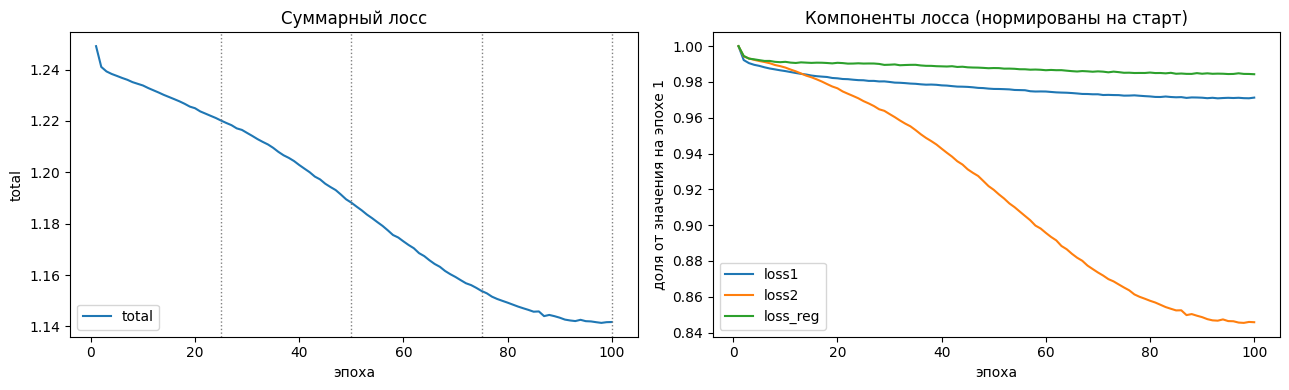

total: эпоха 1 = 1.24910 -> эпоха 100 = 1.14174
изменение за последние 10 эпох: -0.00095  (ещё падает -- горизонт не исчерпан)


In [32]:
hist = pd.DataFrame(final_info["history"]).set_index("epoch")
display(hist.loc[hist.index.isin(MILESTONES)])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist.index, hist["total"], label="total")
for m in MILESTONES:
    if m in hist.index:
        axes[0].axvline(m, color="grey", ls=":", lw=1)
axes[0].set_xlabel("эпоха"); axes[0].set_ylabel("total"); axes[0].set_title("Суммарный лосс")
axes[0].legend()

for col in ("loss1", "loss2", "loss_reg"):
    axes[1].plot(hist.index, hist[col] / hist[col].iloc[0], label=col)
axes[1].set_xlabel("эпоха"); axes[1].set_ylabel("доля от значения на эпохе 1")
axes[1].set_title("Компоненты лосса (нормированы на старт)"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"total: эпоха 1 = {hist['total'].iloc[0]:.5f} -> эпоха {hist.index[-1]} = {hist['total'].iloc[-1]:.5f}")
tail = hist["total"].tail(10)
print(f"изменение за последние 10 эпох: {tail.iloc[-1] - tail.iloc[0]:+.5f}"
      f"  ({'ещё падает -- горизонт не исчерпан' if tail.iloc[-1] < tail.iloc[0] else 'вышел на плато'})")

### Сравнение сабмитов между контрольными точками

Корреляция соседних сабмитов в log-пространстве показывает, насколько модель ещё меняет прогнозы.

In [33]:
subs = {}
for row in submission_log:
    subs[row["epoch"]] = pd.read_csv(SUBMISSIONS_DIR / row["path"]).set_index("user_id")["predict"]

print(pd.DataFrame(submission_log).to_string(index=False))

eps = sorted(subs)
if len(eps) > 1:
    print()
    print("корреляция Пирсона в log1p-пространстве между соседними точками:")
    for a, b in zip(eps, eps[1:]):
        c = np.corrcoef(np.log1p(subs[a]), np.log1p(subs[b]))[0, 1]
        print(f"  ep{a} vs ep{b}: {c:.5f}")

    print()
    print("корреляция каждой точки с последней:")
    for e in eps[:-1]:
        c = np.corrcoef(np.log1p(subs[e]), np.log1p(subs[eps[-1]]))[0, 1]
        print(f"  ep{e} vs ep{eps[-1]}: {c:.5f}")

 epoch                path  mean_predict  median_predict  zeros
    25  cc_or_net_ep25.csv     37.170586        8.372998    0.0
    50  cc_or_net_ep50.csv     39.044008        8.588599    0.0
    75  cc_or_net_ep75.csv     39.403654        8.019990    0.0
   100 cc_or_net_ep100.csv     39.714842        7.949054    0.0

корреляция Пирсона в log1p-пространстве между соседними точками:
  ep25 vs ep50: 0.99019
  ep50 vs ep75: 0.99254
  ep75 vs ep100: 0.99835

корреляция каждой точки с последней:
  ep25 vs ep100: 0.98491
  ep50 vs ep100: 0.99187
  ep75 vs ep100: 0.99835
